# 🏦 FinGuard AI — SHAP Explainability

## Notebook 10 — Explainable AI

This notebook explains the final supervised fraud model using SHAP.

#### Objectives
- Load the final XGBoost fraud model
- Load the final feature metadata and risk-engine results
- Generate global feature importance using SHAP
- Generate SHAP summary and bar plots
- Explain an individual high-risk transaction
- Save explainability artifacts for the application and project report

**Important:** This notebook explains the already-selected final model. It does not retrain the model.


#### 1. Import Libraries

In [1]:
import sys
import warnings
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP is not installed in the current environment. "
        "Run: pip install shap"
    ) from exc

print("FinGuard AI — Explainable AI")
print("=" * 70)
print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)
print("SHAP   :", shap.__version__)


FinGuard AI — Explainable AI
Python : 3.11.15
NumPy  : 2.4.6
Pandas : 3.0.5
SHAP   : 0.51.0


#### 2. Define Project Paths

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Notebooks" else NOTEBOOK_DIR

PROCESSED_DIR = PROJECT_ROOT / "Dataset" / "Processed"
MODEL_DIR = PROJECT_ROOT / "Models"
REPORT_DIR = PROJECT_ROOT / "Reports"

SHAP_DIR = REPORT_DIR / "SHAP"
FIGURES_DIR = REPORT_DIR / "Figures"
MODEL_EVAL_DIR = REPORT_DIR / "Model_Evaluation"

SHAP_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TEST_PATH = PROCESSED_DIR / "feature_engineered_test.csv"

MODEL_CANDIDATES = [
    MODEL_DIR / "optimized_fraud_model.joblib",
    MODEL_DIR / "best_fraud_model.joblib",
    MODEL_DIR / "xgboost_model.joblib",
]

FRAUD_MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), None)

RISK_RESULTS_PATH = MODEL_EVAL_DIR / "risk_engine_results.csv"
RISK_METADATA_PATH = MODEL_DIR / "risk_engine_metadata.joblib"
FINAL_MODEL_METADATA_PATH = MODEL_DIR / "final_model_metadata.joblib"
FEATURE_METADATA_PATH = MODEL_DIR / "feature_engineering_metadata.joblib"

GLOBAL_IMPORTANCE_PATH = SHAP_DIR / "shap_global_feature_importance.csv"
INDIVIDUAL_PATH = SHAP_DIR / "shap_individual_explanation.csv"
SHAP_METADATA_PATH = SHAP_DIR / "shap_metadata.joblib"

SUMMARY_PLOT_PATH = SHAP_DIR / "shap_summary_beeswarm.png"
BAR_PLOT_PATH = SHAP_DIR / "shap_summary_bar.png"
INDIVIDUAL_PLOT_PATH = SHAP_DIR / "shap_individual_waterfall.png"

print("Project Root :", PROJECT_ROOT)
print("Test Data    :", TEST_PATH)
print("Final Model  :", FRAUD_MODEL_PATH)
print("Risk Results :", RISK_RESULTS_PATH)
print("SHAP Folder  :", SHAP_DIR)


Project Root : C:\Users\viqua\Desktop\FinGuard AI
Test Data    : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
Final Model  : C:\Users\viqua\Desktop\FinGuard AI\Models\optimized_fraud_model.joblib
Risk Results : C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\risk_engine_results.csv
SHAP Folder  : C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP


#### 3. Validate Required Artifacts

In [3]:
required = {
    "Test Dataset": TEST_PATH,
    "Final Fraud Model": FRAUD_MODEL_PATH,
    "Risk Results": RISK_RESULTS_PATH,
    "Risk Metadata": RISK_METADATA_PATH,
}

for name, path in required.items():
    exists = path is not None and Path(path).exists()
    print(("✓ EXISTS" if exists else "✗ MISSING").ljust(12), name, ":", path)

missing = [name for name, path in required.items()
           if path is None or not Path(path).exists()]

if missing:
    raise FileNotFoundError(
        f"Required Explainable AI artifacts are missing: {missing}"
    )

print("\n✓ Required artifact validation passed")


✓ EXISTS     Test Dataset : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
✓ EXISTS     Final Fraud Model : C:\Users\viqua\Desktop\FinGuard AI\Models\optimized_fraud_model.joblib
✓ EXISTS     Risk Results : C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\risk_engine_results.csv
✓ EXISTS     Risk Metadata : C:\Users\viqua\Desktop\FinGuard AI\Models\risk_engine_metadata.joblib

✓ Required artifact validation passed


#### 4. Load Final Model and Data

In [4]:
test_df = pd.read_csv(TEST_PATH)
risk_results = pd.read_csv(RISK_RESULTS_PATH)

fraud_model = joblib.load(FRAUD_MODEL_PATH)
risk_metadata = joblib.load(RISK_METADATA_PATH)

print("✓ Test dataset loaded :", test_df.shape)
print("✓ Risk results loaded :", risk_results.shape)
print("✓ Final model         :", type(fraud_model).__name__)
print("✓ Risk metadata type  :", type(risk_metadata).__name__)


✓ Test dataset loaded : (56746, 54)
✓ Risk results loaded : (56746, 9)
✓ Final model         : XGBClassifier
✓ Risk metadata type  : dict


#### 5. Resolve the Final Feature Set

In [5]:
TARGET = "Class"

if isinstance(risk_metadata, dict) and risk_metadata.get("feature_columns"):
    feature_columns = list(risk_metadata["feature_columns"])
elif hasattr(fraud_model, "feature_names_in_"):
    feature_columns = list(fraud_model.feature_names_in_)
else:
    feature_columns = [c for c in test_df.columns if c != TARGET]

missing_features = [c for c in feature_columns if c not in test_df.columns]
if missing_features:
    raise ValueError(f"Missing model features: {missing_features[:20]}")

X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].astype(int).copy() if TARGET in test_df.columns else None

if X_test.isnull().any().any():
    raise ValueError("Missing values detected in SHAP feature matrix.")

if np.isinf(X_test.to_numpy()).any():
    raise ValueError("Infinite values detected in SHAP feature matrix.")

print("Target       :", TARGET)
print("Feature count:", len(feature_columns))
print("Test samples :", len(X_test))


Target       : Class
Feature count: 53
Test samples : 56746


#### 6. Verify Model / Feature Compatibility

In [6]:
if hasattr(fraud_model, "n_features_in_"):
    expected = int(fraud_model.n_features_in_)
    actual = X_test.shape[1]
    print("Model expects :", expected)
    print("Data contains :", actual)

    if expected != actual:
        raise ValueError(
            f"Feature mismatch: model expects {expected}, data contains {actual}."
        )

print("✓ Model and feature matrix are compatible")


Model expects : 53
Data contains : 53
✓ Model and feature matrix are compatible


#### 7. Select SHAP Analysis Sample

The test set contains tens of thousands of transactions. For efficient visualization, SHAP is calculated on a reproducible sample while preserving the full feature space.


In [7]:
SHAP_SAMPLE_SIZE = min(5000, len(X_test))
SHAP_RANDOM_STATE = 42

if len(X_test) > SHAP_SAMPLE_SIZE:
    X_shap = X_test.sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=SHAP_RANDOM_STATE
    ).copy()
else:
    X_shap = X_test.copy()

print(f"✓ SHAP samples selected: {len(X_shap):,}")
print(f"✓ Features             : {X_shap.shape[1]}")


✓ SHAP samples selected: 5,000
✓ Features             : 53


#### 8. Create SHAP Tree Explainer

In [8]:
start = time.time()

try:
    explainer = shap.TreeExplainer(fraud_model)
except Exception as exc:
    raise RuntimeError(
        "TreeExplainer could not be created for the selected final model."
    ) from exc

print("✓ SHAP TreeExplainer created")
print(f"✓ Initialization time: {time.time() - start:.3f} seconds")


✓ SHAP TreeExplainer created
✓ Initialization time: 0.143 seconds


#### 9. Calculate SHAP Values

In [9]:
start = time.time()

shap_output = explainer(X_shap)

# SHAP can return different structures depending on the model/version.
if hasattr(shap_output, "values"):
    shap_values = shap_output.values
else:
    shap_values = shap_output

if isinstance(shap_values, list):
    # For binary classifiers, use the positive/fraud class explanation.
    shap_values = shap_values[1]

shap_values = np.asarray(shap_values)

# Some SHAP/model combinations can return an extra output dimension.
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

if shap_values.shape != X_shap.shape:
    raise ValueError(
        f"Unexpected SHAP shape {shap_values.shape}; "
        f"expected {X_shap.shape}."
    )

print("✓ SHAP values calculated")
print("SHAP shape :", shap_values.shape)
print(f"Calculation time: {time.time() - start:.2f} seconds")


✓ SHAP values calculated
SHAP shape : (5000, 53)
Calculation time: 12.55 seconds


## 10. Global SHAP Feature Importance

In [10]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

global_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

global_importance["Importance_Rank"] = np.arange(
    1, len(global_importance) + 1
)

display(global_importance.head(20))

global_importance.to_csv(
    GLOBAL_IMPORTANCE_PATH,
    index=False
)

print("✓ Global feature importance saved:")
print(GLOBAL_IMPORTANCE_PATH)


,Feature,Mean_Absolute_SHAP,Importance_Rank
0,V14,2.180112,1
1,V4,1.445570,2
2,V8,0.824416,3
3,V12,0.820665,4
4,V10,0.673070,5
5,V11,0.634191,6
6,V18,0.570184,7
7,V3,0.558390,8
8,V_Abs_Std,0.516430,9
9,V1,0.480867,10


✓ Global feature importance saved:
C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_global_feature_importance.csv


## 11. SHAP Summary — Bar Plot

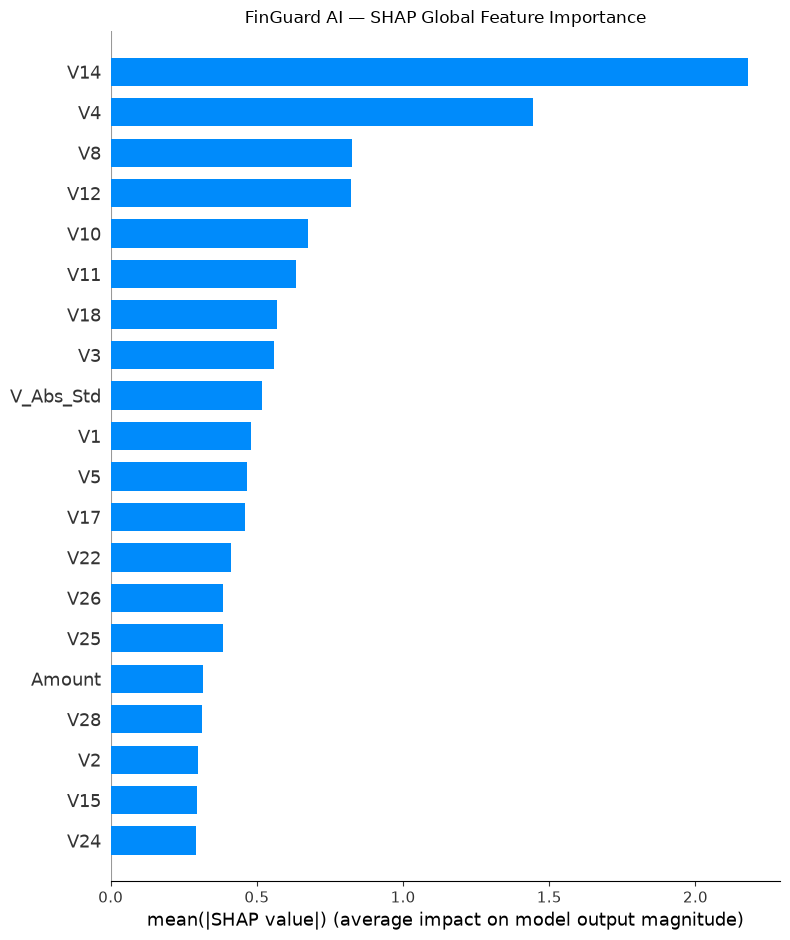

✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_summary_bar.png


In [11]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("FinGuard AI — SHAP Global Feature Importance")
plt.tight_layout()
plt.savefig(BAR_PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✓ Saved:", BAR_PLOT_PATH)


## 12. SHAP Summary — Beeswarm Plot

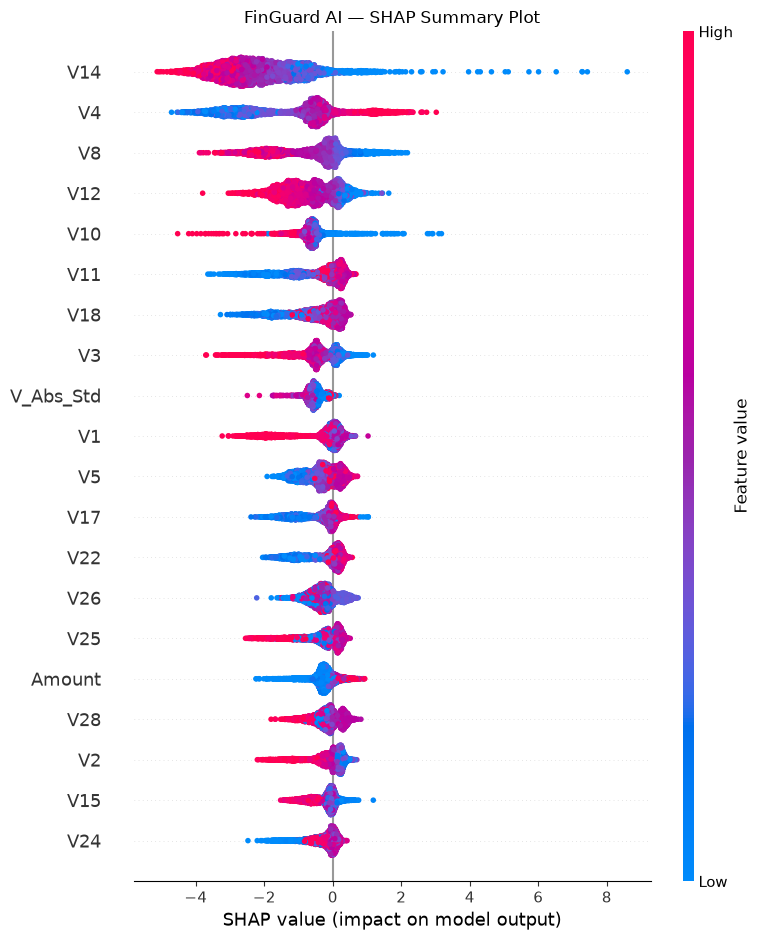

✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_summary_beeswarm.png


In [12]:
plt.figure(figsize=(11, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20,
    show=False
)

plt.title("FinGuard AI — SHAP Summary Plot")
plt.tight_layout()
plt.savefig(SUMMARY_PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✓ Saved:", SUMMARY_PLOT_PATH)


## 13. Identify the Highest-Risk Transaction

The Risk Engine output is used only to select a meaningful transaction for explanation. The final fraud model itself remains the model being explained.


In [13]:
if "Risk_Score" in risk_results.columns:
    selected_index = risk_results["Risk_Score"].astype(float).idxmax()
else:
    selected_index = risk_results["Fraud_Probability"].astype(float).idxmax()

selected_index = int(selected_index)

if selected_index >= len(X_test):
    raise IndexError(
        "Risk result index does not align with the test dataset."
    )

transaction = X_test.iloc[selected_index:selected_index + 1].copy()

if "Risk_Level" in risk_results.columns:
    selected_risk_level = risk_results.loc[selected_index, "Risk_Level"]
else:
    selected_risk_level = "Unknown"

selected_risk_score = (
    float(risk_results.loc[selected_index, "Risk_Score"])
    if "Risk_Score" in risk_results.columns else np.nan
)

print("Selected transaction index:", selected_index)
print("Risk level               :", selected_risk_level)
print("Risk score               :", selected_risk_score)


Selected transaction index: 8671
Risk level               : High
Risk score               : 96.81678184360965


## 14. Explain the Selected Transaction

In [14]:
individual_output = explainer(transaction)

if hasattr(individual_output, "values"):
    individual_values = individual_output.values
else:
    individual_values = individual_output

if isinstance(individual_values, list):
    individual_values = individual_values[1]

individual_values = np.asarray(individual_values)

if individual_values.ndim == 3:
    individual_values = individual_values[:, :, 1]

individual_values = individual_values.reshape(-1)

if len(individual_values) != len(feature_columns):
    raise ValueError("Individual SHAP explanation does not match feature count.")

individual_explanation = pd.DataFrame({
    "Feature": feature_columns,
    "Feature_Value": transaction.iloc[0].to_numpy(),
    "SHAP_Value": individual_values,
    "Absolute_SHAP": np.abs(individual_values)
}).sort_values(
    "Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

individual_explanation["Impact"] = np.where(
    individual_explanation["SHAP_Value"] >= 0,
    "Increases Fraud Probability",
    "Decreases Fraud Probability"
)

display(individual_explanation.head(20))


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP,Impact
0,V4,9.584969,3.135551,3.135551,Increases Fraud Probability
1,V14,0.116303,-2.686888,2.686888,Decreases Fraud Probability
2,V10,-19.836149,2.581360,2.581360,Increases Fraud Probability
3,V8,-21.560039,1.695706,1.695706,Increases Fraud Probability
4,V12,-10.895134,1.289648,1.289648,Increases Fraud Probability
5,V17,-18.108261,1.129419,1.129419,Increases Fraud Probability
6,V7,-33.239328,1.128672,1.128672,Increases Fraud Probability
7,V3,-22.209875,0.860763,0.860763,Increases Fraud Probability
8,V5,-16.230439,-0.683465,0.683465,Decreases Fraud Probability
9,Amount,-0.355570,-0.677228,0.677228,Decreases Fraud Probability


## 15. Save Individual Explanation

In [15]:
individual_explanation.to_csv(
    INDIVIDUAL_PATH,
    index=False
)

print("✓ Individual explanation saved:")
print(INDIVIDUAL_PATH)


✓ Individual explanation saved:
C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_individual_explanation.csv


## 16. Individual SHAP Waterfall Plot

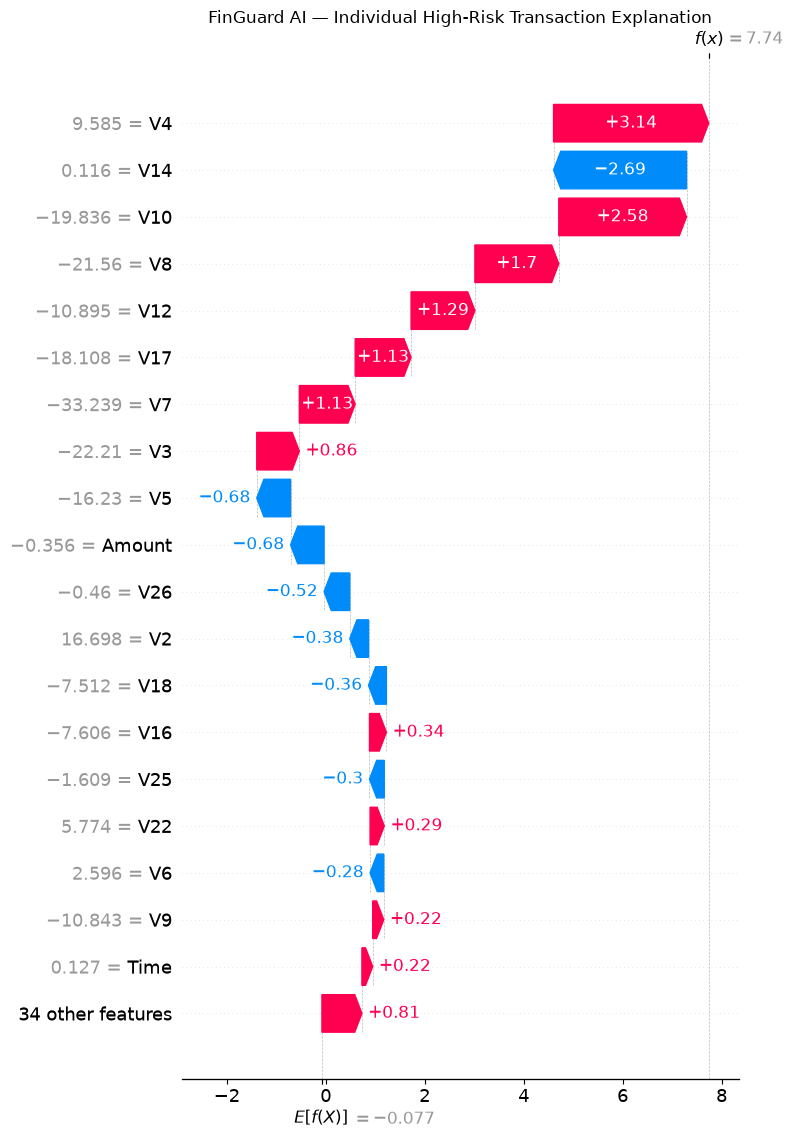

✓ Saved: C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_individual_waterfall.png


In [16]:
# Build a single-row Explanation object for the selected transaction.
single_shap_output = explainer(transaction)

if hasattr(single_shap_output, "values"):
    single_values = single_shap_output.values
    base_values = single_shap_output.base_values
else:
    single_values = single_shap_output
    base_values = getattr(explainer, "expected_value", 0)

if isinstance(single_values, list):
    single_values = single_values[1]

single_values = np.asarray(single_values)
if single_values.ndim == 3:
    single_values = single_values[:, :, 1]

single_values = single_values[0]

if isinstance(base_values, (list, np.ndarray)):
    base_values = np.asarray(base_values).reshape(-1)
    base_value = float(base_values[-1])
else:
    base_value = float(base_values)

explanation = shap.Explanation(
    values=single_values,
    base_values=base_value,
    data=transaction.iloc[0].to_numpy(),
    feature_names=feature_columns
)

plt.figure(figsize=(11, 8))
shap.plots.waterfall(
    explanation,
    max_display=20,
    show=False
)
plt.title("FinGuard AI — Individual High-Risk Transaction Explanation")
plt.tight_layout()
plt.savefig(INDIVIDUAL_PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✓ Saved:", INDIVIDUAL_PLOT_PATH)


## 17. SHAP Metadata

In [17]:
shap_metadata = {
    "project": "FinGuard AI",
    "explainability_method": "SHAP TreeExplainer",
    "model_type": type(fraud_model).__name__,
    "model_path": str(FRAUD_MODEL_PATH),
    "feature_count": len(feature_columns),
    "feature_columns": feature_columns,
    "test_samples": int(len(X_test)),
    "shap_samples": int(len(X_shap)),
    "random_state": SHAP_RANDOM_STATE,
    "global_importance_path": str(GLOBAL_IMPORTANCE_PATH),
    "summary_beeswarm_path": str(SUMMARY_PLOT_PATH),
    "summary_bar_path": str(BAR_PLOT_PATH),
    "individual_explanation_path": str(INDIVIDUAL_PATH),
    "individual_waterfall_path": str(INDIVIDUAL_PLOT_PATH),
    "selected_transaction_index": selected_index,
    "selected_risk_level": str(selected_risk_level),
    "selected_risk_score": selected_risk_score
}

joblib.dump(shap_metadata, SHAP_METADATA_PATH)

print("✓ SHAP metadata saved:")
print(SHAP_METADATA_PATH)


✓ SHAP metadata saved:
C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_metadata.joblib


## 18. Validate Explainability Artifacts

In [18]:
expected_outputs = [
    GLOBAL_IMPORTANCE_PATH,
    INDIVIDUAL_PATH,
    SUMMARY_PLOT_PATH,
    BAR_PLOT_PATH,
    INDIVIDUAL_PLOT_PATH,
    SHAP_METADATA_PATH
]

print("Generated Explainable AI Artifacts")
print("=" * 70)

for path in expected_outputs:
    print(
        ("✓ EXISTS" if Path(path).exists() else "✗ MISSING").ljust(12),
        path
    )

if not all(Path(path).exists() for path in expected_outputs):
    raise RuntimeError(
        "One or more Explainable AI artifacts were not created."
    )

print("\n✓ Explainability artifact validation passed")


Generated Explainable AI Artifacts
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_global_feature_importance.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_individual_explanation.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_summary_beeswarm.png
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_summary_bar.png
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_individual_waterfall.png
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\SHAP\shap_metadata.joblib

✓ Explainability artifact validation passed


## 19. Final Explainable AI Summary

In [19]:
print("=" * 75)
print("FIN GUARD AI — EXPLAINABLE AI COMPLETED")
print("=" * 75)
print(f"✓ Model                  : {type(fraud_model).__name__}")
print(f"✓ Features               : {len(feature_columns)}")
print(f"✓ Test Samples           : {len(X_test):,}")
print(f"✓ SHAP Samples           : {len(X_shap):,}")
print(f"✓ Top Feature            : {global_importance.iloc[0]['Feature']}")
print(f"✓ Top SHAP Importance    : {global_importance.iloc[0]['Mean_Absolute_SHAP']:.6f}")
print(f"✓ Explained Transaction  : {selected_index}")
print(f"✓ Selected Risk Level    : {selected_risk_level}")
print(f"✓ Selected Risk Score    : {selected_risk_score:.2f}")
print("✓ Global SHAP Artifacts  : Saved")
print("✓ Individual Explanation : Saved")
print("=" * 75)


FIN GUARD AI — EXPLAINABLE AI COMPLETED
✓ Model                  : XGBClassifier
✓ Features               : 53
✓ Test Samples           : 56,746
✓ SHAP Samples           : 5,000
✓ Top Feature            : V14
✓ Top SHAP Importance    : 2.180112
✓ Explained Transaction  : 8671
✓ Selected Risk Level    : High
✓ Selected Risk Score    : 96.82
✓ Global SHAP Artifacts  : Saved
✓ Individual Explanation : Saved


## 20. Next Stage — Application / Deployment Integration

The explainability artifacts generated here are ready for integration into the FinGuard AI application.

Planned application capabilities:
- Fraud prediction
- Risk score and risk level
- Transaction-level explanation
- Top contributing features
- SHAP visualizations
- Analytics dashboard
- API integration
- Final testing and documentation
